## Assignment 06 _ Weather
**Author** - Alec Reid

**Date** - 12.11.2025

----


Get the data from this link.

https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv


Plot:

- The temperature
- The mean temperature each day
- The mean temperature for each month

Plot:

- The Windspeed (there is data missing from this column)
- The rolling windspeed (say over 24 hours)
- The max windspeed for each day
- The monthly mean of the daily max windspeeds 
- You do not need to over comment your code. Marks will be given for how nice the plots are.

------

**Note to self**

CSV for assignment is saved in repository as KnockWeatherData.csv

--------

#### (1) Tidy Up Dataframe So We Can Use It

In [43]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt

After investigating the data we can see all the actual starts on row 24 so lets start there

In [56]:
# Read in the data, skipping the first 23 rows have a look at first 5 rows
df= pd.read_csv("C:\AlecProjects\PFDA_2025\KnockWeatherData.csv",skiprows=23)
df.head()

C:\Users\Alec\AppData\Local\Temp\ipykernel_11348\1571452192.py:2: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("C:\AlecProjects\PFDA_2025\KnockWeatherData.csv",skiprows=23)


,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
0,10-apr-1996 14:00,0,0.0,0,11.5,0,8.1,3.9,0.0,0,...,0,0,0,0,25,81,0.0,35000,32,5
1,31-jul-1996 08:00,0,0.0,0,11.5,0,11.1,10.7,0.0,0,...,0,0,0,0,25,82,0.0,40000,45,5
2,31-jul-1996 09:00,0,0.0,0,11.6,0,10.7,9.8,0.0,0,...,0,0,0,0,80,81,0.0,8000,32,7
3,31-jul-1996 10:00,0,0.0,0,12.9,0,11.3,9.8,0.0,0,...,0,0,0,0,25,82,0.0,28000,35,6
4,31-jul-1996 11:00,0,0.0,0,14.5,0,10.8,7.0,0.0,0,...,0,0,0,0,2,11,0.0,40000,40,6


In [57]:
# Look at the last 5 rows
df.tail()

,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,...,ind.3,wdsp,ind.4,wddir,ww,w,sun,vis,clht,clamt
256429,31-oct-2025 20:00,0,0.0,0,8.6,0,7.8,6.8,9.9,89,...,2,13,2,160,,,0.0,35000,90,8
256430,31-oct-2025 21:00,0,0.0,0,8.3,0,7.8,7.2,10.2,93,...,2,13,2,160,,,0.0,22000,90,8
256431,31-oct-2025 22:00,0,0.5,0,7.8,0,7.6,7.3,10.3,97,...,2,10,2,160,,,0.0,6000,43,8
256432,31-oct-2025 23:00,0,0.8,0,7.4,0,7.3,7.2,10.1,99,...,2,8,2,160,,,0.0,9000,46,8
256433,01-nov-2025 00:00,0,0.2,0,7.4,0,7.4,7.3,10.3,100,...,2,7,2,190,,,0.0,25000,1,8


Some of these are multiple dates for the same date 

In [58]:
# Get the info on the dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256434 entries, 0 to 256433
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    256434 non-null  object 
 1   ind     256434 non-null  int64  
 2   rain    256434 non-null  object 
 3   ind.1   256434 non-null  int64  
 4   temp    256434 non-null  float64
 5   ind.2   256434 non-null  int64  
 6   wetb    256434 non-null  float64
 7   dewpt   256434 non-null  float64
 8   vappr   256434 non-null  float64
 9   rhum    256434 non-null  int64  
 10  msl     256434 non-null  object 
 11  ind.3   256434 non-null  int64  
 12  wdsp    256434 non-null  object 
 13  ind.4   256434 non-null  int64  
 14  wddir   256434 non-null  object 
 15  ww      256434 non-null  object 
 16  w       256434 non-null  object 
 17  sun     256434 non-null  float64
 18  vis     256434 non-null  object 
 19  clht    256434 non-null  object 
 20  clamt   256434 non-null  object 
dtypes: float64

#### Apply the date time index 

In [59]:
# Exclude dates with null values for temp
df = df.dropna(subset=['temp'])

In [60]:
# Convert the 'date' colummn to datetime and set it as the index
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%Y %H:%M') # looking at the date format we cn see it is day-month-year hour:minute (although minute is probably alway 00)
df.set_index('date', inplace=True)

In [63]:
# show the number of unique dates in the dataframe
unique_dates = df.index.normalize().nunique()
print(f"Number of unique dates in the dataframe: {unique_dates}")

Number of unique dates in the dataframe: 10687


----------------

#### (2) Plot the Temperature 

<Axes: title={'center': 'Temperature Over Time'}, xlabel='Date', ylabel='Temperature (°C)'>

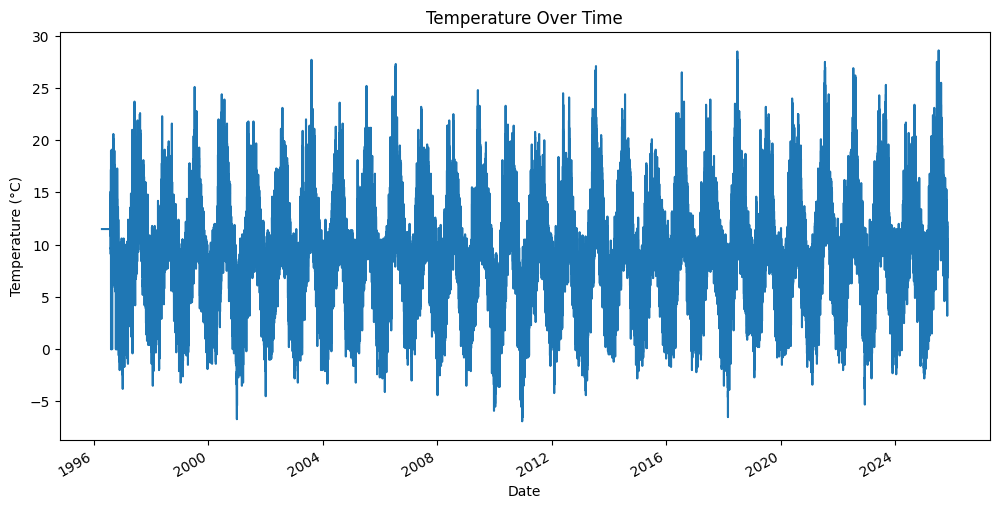

In [62]:
# Plot the 'temp' column
df['temp'].plot(title='Temperature Over Time', figsize=(12, 6), xlabel='Date', ylabel='Temperature (°C)')

In [37]:
# Find the date and value of the lowest temperature
lowest_temp = df['temp'].idxmin()
lowest_temp_value = df['temp'].min()
print(f"Lowest temperature: {lowest_temp_value}°C on {lowest_temp}")

# Find the date and value of the highest temperature
highest_temp = df['temp'].idxmax()
highest_temp_value = df['temp'].max()
print(f"Highest temperature: {highest_temp_value}°C on {highest_temp}")

# Calculate the average temperature
average_temp = df['temp'].mean()
print(f"Average temperature: {average_temp:.2f}°C")

Lowest temperature: -6.9°C on 2010-12-20 12:00:00
Highest temperature: 28.6°C on 2025-07-12 16:00:00
Average temperature: 8.80°C


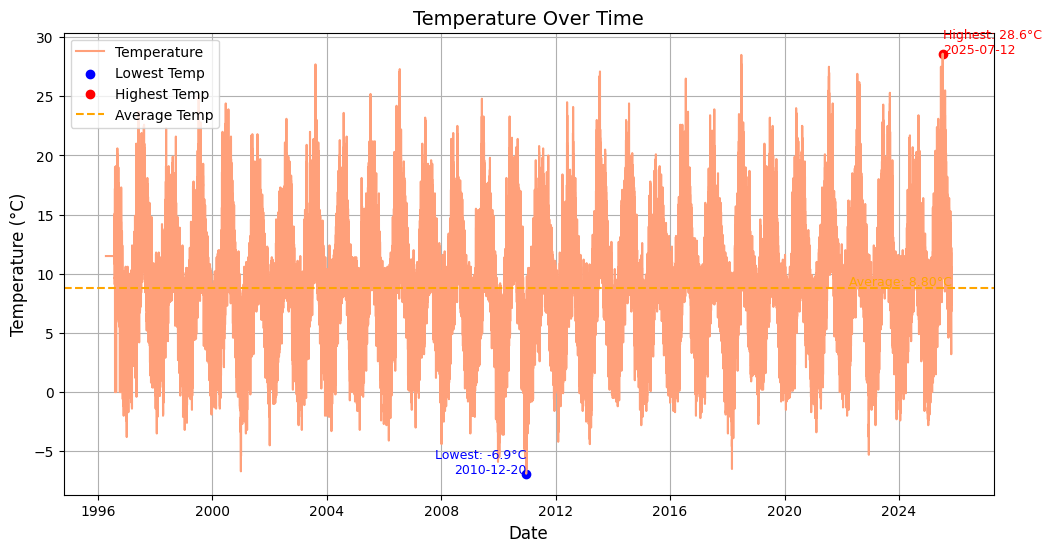

In [82]:
# Plot the temperature data
plt.figure(figsize=(12, 6))
plt.plot(df['temp'], label='Temperature', color='lightsalmon')

# Highlight the lowest temperature
plt.scatter(lowest_temp, lowest_temp_value, color='blue', label='Lowest Temp')
plt.text(lowest_temp, lowest_temp_value, f'Lowest: {lowest_temp_value}°C\n{lowest_temp.date()}', 
         color='blue', fontsize=9, ha='right')

# Highlight the highest temperature
plt.scatter(highest_temp, highest_temp_value, color='red', label='Highest Temp')
plt.text(highest_temp, highest_temp_value, f'Highest: {highest_temp_value}°C\n{highest_temp.date()}', 
         color='red', fontsize=9, ha='left')

# highlight the average temperature line
plt.axhline(average_temp, color='orange', linestyle='--', label='Average Temp')
plt.text(df.index[-1], average_temp, f'Average: {average_temp:.2f}°C', 
         color='orange', fontsize=9, va='bottom', ha='right')   

# Add labels, title, and legend
plt.title('Temperature Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

#### (2.) The Mean Temperature Each Day

I'm going to take as an example the hottest day ever recorded just to get my head around how I am going to do this 

In [68]:
# Filter the dataframe for the date 2025-07-12
temps_on_2025_07_12 = df.loc['2025-07-12', 'temp']
print(temps_on_2025_07_12)

date
2025-07-12 00:00:00    15.2
2025-07-12 01:00:00    14.7
2025-07-12 02:00:00    15.0
2025-07-12 03:00:00    14.4
2025-07-12 04:00:00    14.3
2025-07-12 05:00:00    13.5
2025-07-12 06:00:00    15.0
2025-07-12 07:00:00    16.7
2025-07-12 08:00:00    19.3
2025-07-12 09:00:00    22.1
2025-07-12 10:00:00    24.2
2025-07-12 11:00:00    25.3
2025-07-12 12:00:00    25.8
2025-07-12 13:00:00    26.4
2025-07-12 14:00:00    27.7
2025-07-12 15:00:00    27.8
2025-07-12 16:00:00    28.6
2025-07-12 17:00:00    28.5
2025-07-12 18:00:00    27.3
2025-07-12 19:00:00    26.5
2025-07-12 20:00:00    23.3
2025-07-12 21:00:00    22.1
2025-07-12 22:00:00    20.7
2025-07-12 23:00:00    19.3
Name: temp, dtype: float64


In [73]:
# Mean temperature on 2025-07-12
mean_temp_2025_07_12 = temps_on_2025_07_12.mean()
print(f"Mean temperature on 2025-07-12: {mean_temp_2025_07_12:.2f}°C")

Mean temperature on 2025-07-12: 21.40°C


Okay - we just need to find the mean for every unique date in the dataframe 

In [74]:
# Mean temperature for every unique date in the dataframe
daily_mean_temp = df['temp'].resample('D').mean()
print(daily_mean_temp)

date
1996-04-10    11.500000
1996-04-11          NaN
1996-04-12          NaN
1996-04-13          NaN
1996-04-14          NaN
                ...    
2025-10-28     8.604167
2025-10-29     6.612500
2025-10-30     7.887500
2025-10-31     9.670833
2025-11-01     7.400000
Freq: D, Name: temp, Length: 10798, dtype: float64


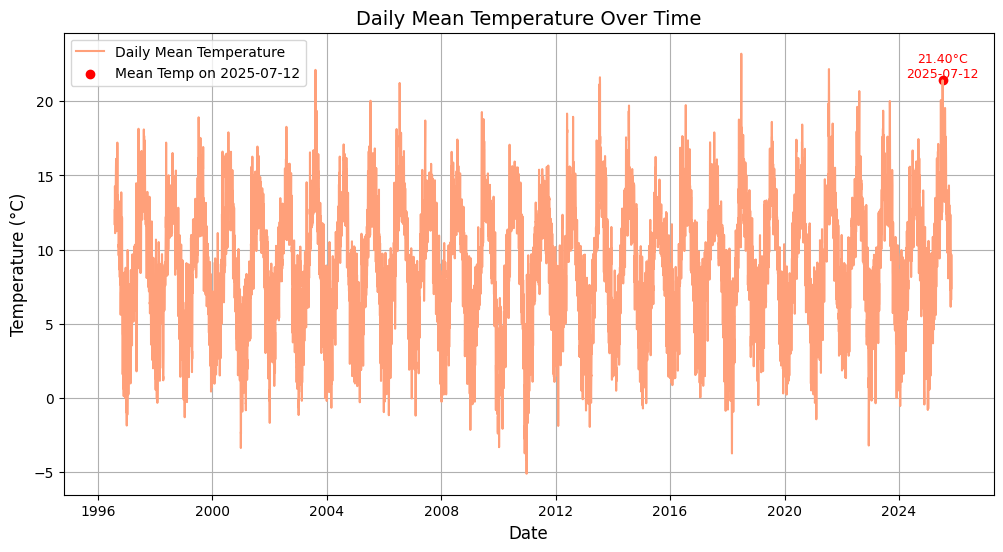

In [81]:
# Plot the daily mean temperature
plt.figure(figsize=(12, 6))
plt.plot(daily_mean_temp, label='Daily Mean Temperature', color='lightsalmon')

# Highlight the mean temperature on 2025-07-12 (Calling this one out as a tester as I found the mean for the hottest day above)
highlight_date = pd.to_datetime('2025-07-12')  # Convert to datetime
highlight_temp = mean_temp_2025_07_12
plt.scatter(highlight_date, highlight_temp, color='red', label=f'Mean Temp on {highlight_date.date()}')
plt.text(highlight_date, highlight_temp, f'{highlight_temp:.2f}°C\n{highlight_date.date()}', 
         color='red', fontsize=9, ha='center', va='bottom')

# Add labels, title, and legend
plt.title('Daily Mean Temperature Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

#### (3.) Mean Temperature for Each Month

In [ ]:
# Ceate unique months in the dataframe
monthly_mean_temp = df['temp'].resample('M').mean() #  We can use the resample function because we modified date to Datetimeindex 
print(monthly_mean_temp)

date
1996-04-30    11.500000
1996-05-31          NaN
1996-06-30          NaN
1996-07-31    12.650000
1996-08-31    12.946909
                ...    
2025-07-31    15.068280
2025-08-31    15.178495
2025-09-30    11.368056
2025-10-31     9.900134
2025-11-30     7.400000
Freq: M, Name: temp, Length: 356, dtype: float64


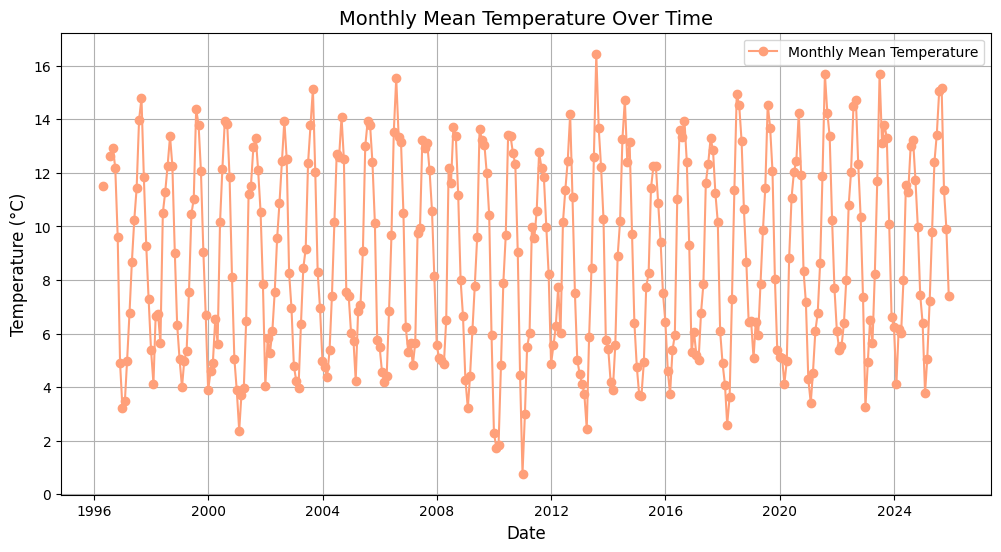

In [85]:
# PLot the monthly mean temperature
plt.figure(figsize=(12, 6))
plt.plot(monthly_mean_temp, marker='o', label='Monthly Mean Temperature', color='lightsalmon')

# Add labels, title, and legend
plt.title('Monthly Mean Temperature Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


Lets plot it for 2024 and see what the make sure there are 12 months shown. Lets also look at advrages to make sure all checks out 

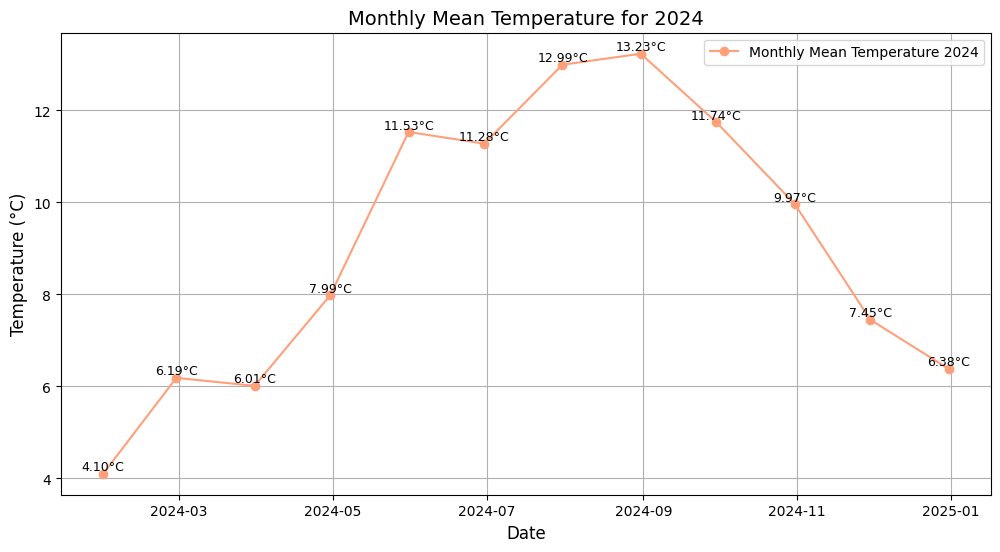

In [90]:
# Plot montly mean temperature for months that occured in year 2024
plt.figure(figsize=(12, 6))
monthly_mean_temp_2024 = monthly_mean_temp[monthly_mean_temp.index.year == 2024]
plt.plot(monthly_mean_temp_2024, marker='o', label='Monthly Mean Temperature 2024', color='lightsalmon')   

#Highlight each month point with its value
for date, temp in monthly_mean_temp_2024.items():
    plt.text(date, temp, f'{temp:.2f}°C', color='black', fontsize=9, ha='center', va='bottom')

# Add labels, title, and legend
plt.title('Monthly Mean Temperature for 2024', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


Haha that's pretty cool - check it against met eireann and the average for Mayo in August was 13.3 and we got 13.23 for Knock with our plot. (https://www.met.ie/climate-statement-for-august-2024?utm)

-----------

#### (4.) Windspeed

In [92]:
# Exclude dates with null values for windspeed
df_wind = df.dropna(subset=['wdsp'])